# Lecture 15, Notebook 03b: Joint structural estimation via SMM — Brock--Mirman with \((\beta,\varrho)\)

This updated joint notebook keeps the same minimal structure as the scalar exercise:

1. train a single policy surrogate with both parameters as pseudo-states;
2. generate synthetic data at \((\beta_{true},\varrho_{true})=(0.96,0.90)\);
3. evaluate simulated moments over a two-dimensional parameter grid under common random numbers;
4. recover the parameters by SMM and inspect identification through contour plots and a moment Jacobian.

The previous active-learning and BoTorch material has been removed from the main notebook.  It is better treated as an optional research extension after the basic SMM estimator is clear.


In [1]:
SEED = 0

import numpy as np
import torch
try:
    torch.set_num_threads(2)
    torch.set_num_interop_threads(2)
except RuntimeError:
    pass
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")

# Flip to True to write the slide-deck / chapter PDF figures into FIG_DIR.
# Defaults to False so the notebook can be re-run without overwriting the
# figures that ship with the slides.
SAVE_FIGURES = False
FIG_DIR = Path("../slides/fig")


def _save_fig(fig, name):
    if SAVE_FIGURES:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / name, bbox_inches="tight")


plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 12

print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"SAVE_FIGURES = {SAVE_FIGURES}; FIG_DIR = {FIG_DIR.resolve() if SAVE_FIGURES else '(inline only)'}")


Using device: cpu
PyTorch version: 2.10.0+cpu
Inline figures enabled; optional figure directory: /mnt/data/fig


## 1. Joint pseudo-state surrogate

The network takes \((z,K,\beta,\varrho)\) as inputs and returns the savings rate.  Training uses the same Euler residual as in the scalar notebook, except that \(\beta\) now varies across the training batch.


In [2]:
alpha   = 0.36
delta   = 0.10
sigma_z = 0.04

beta_lo, beta_hi = 0.92, 0.99
rho_lo, rho_hi   = 0.50, 0.99
z_lo, z_hi       = 0.70, 1.30
k_lo, k_hi       = 0.50, 12.0

beta_true = 0.96
rho_true  = 0.90

N_TRAIN = 200
BATCH_SIZE = 256
LEARNING_RATE = 5e-4

n_gh = 5
gh_nodes, gh_weights = np.polynomial.hermite.hermgauss(n_gh)
gh_weights = gh_weights / np.sqrt(np.pi)
gh_nodes   = gh_nodes * np.sqrt(2.0)

x_int = torch.tensor(gh_nodes * sigma_z, dtype=torch.float32, device=device)
w_gh  = torch.tensor(gh_weights, dtype=torch.float32, device=device)

# Steady-state anchors across beta.  They stabilize the classroom-scale training run.
def steady_state(beta_value):
    K = (alpha / (1.0 / beta_value - 1.0 + delta)) ** (1.0 / (1.0 - alpha))
    s = delta * K / (K ** alpha)
    return K, s

beta_anchor = torch.linspace(beta_lo, beta_hi, 16, device=device).reshape(-1, 1)
K_anchor_values, s_anchor_values = [], []
for b in beta_anchor.squeeze().cpu().numpy():
    K_a, s_a = steady_state(float(b))
    K_anchor_values.append(K_a)
    s_anchor_values.append(s_a)
X_anchor = torch.cat([
    torch.ones_like(beta_anchor),
    torch.tensor(K_anchor_values, dtype=torch.float32, device=device).reshape(-1, 1),
    beta_anchor,
    torch.full_like(beta_anchor, rho_true),
], dim=1)
s_anchor = torch.tensor(s_anchor_values, dtype=torch.float32, device=device).reshape(-1, 1)

print(f"Parameter box: beta in [{beta_lo}, {beta_hi}], rho in [{rho_lo}, {rho_hi}]")
print(f"Synthetic truth: beta={beta_true}, rho={rho_true}")
print(f"Steady-state anchor at beta=.96: K*={steady_state(beta_true)[0]:.3f}, s*={steady_state(beta_true)[1]:.3f}")


Parameter box: beta in [0.92, 0.99], rho in [0.5, 0.99]
Synthetic truth: beta=0.96, rho=0.9
Steady-state anchor at beta=.96: K*=4.294, s*=0.254


In [3]:
class JointPolicyNet(nn.Module):
    """(z, K, beta, rho) -> output-based savings rate s in (0,1)."""
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, 1), nn.Sigmoid(),
        )
        nn.init.zeros_(self.net[-2].weight)
        nn.init.constant_(self.net[-2].bias, np.log(0.25 / 0.75))

    def forward(self, x):
        return self.net(x)


def sample_joint_states(n):
    z    = torch.rand(n, 1, device=device) * (z_hi - z_lo) + z_lo
    K    = torch.rand(n, 1, device=device) * (k_hi - k_lo) + k_lo
    beta = torch.rand(n, 1, device=device) * (beta_hi - beta_lo) + beta_lo
    rho  = torch.rand(n, 1, device=device) * (rho_hi - rho_lo) + rho_lo
    return torch.cat([z, K, beta, rho], dim=1)


def euler_loss_joint(X, policy, anchor_weight=1e-3):
    z_t    = X[:, 0:1]
    K_t    = X[:, 1:2]
    beta_t = X[:, 2:3]
    rho_t  = X[:, 3:4]

    Y_t   = z_t * K_t**alpha
    s_t   = policy(X)
    K_tp1 = (1.0 - delta) * K_t + Y_t * s_t
    C_t   = Y_t * (1.0 - s_t)

    expectation = torch.zeros_like(C_t)
    for j in range(n_gh):
        z_tp1 = torch.exp(rho_t * torch.log(z_t) + x_int[j])
        X_tp1 = torch.cat([z_tp1, K_tp1, beta_t, rho_t], dim=1)
        Y_tp1 = z_tp1 * K_tp1**alpha
        s_tp1 = policy(X_tp1)
        C_tp1 = Y_tp1 * (1.0 - s_tp1)
        r_tp1 = alpha * z_tp1 * K_tp1**(alpha - 1.0)
        expectation = expectation + w_gh[j] * (1.0 - delta + r_tp1) / C_tp1

    relative_error = 1.0 / (beta_t * C_t * expectation) - 1.0
    loss = torch.mean(relative_error**2)
    loss = loss + anchor_weight * torch.mean((policy(X_anchor) - s_anchor)**2)
    return loss, relative_error


policy = JointPolicyNet().to(device)
optimizer = torch.optim.Adam(policy.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_TRAIN, eta_min=1e-5)

losses = []
for step in range(N_TRAIN):
    X = sample_joint_states(BATCH_SIZE)
    loss, _ = euler_loss_joint(X, policy)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    losses.append(float(loss.detach().cpu()))
    if (step + 1) % 200 == 0:
        X_check = torch.tensor([[1.0, steady_state(beta_true)[0], beta_true, rho_true]], dtype=torch.float32, device=device)
        with torch.no_grad():
            s_check = float(policy(X_check).cpu())
        print(f"step {step+1:4d}/{N_TRAIN} | loss={losses[-1]:.3e} | s(z=1,K*,beta=.96,rho=.90)={s_check:.4f}")

policy.eval()
print(f"Final Euler-plus-anchor loss: {losses[-1]:.3e}")
print(f"Policy network parameters: {sum(p.numel() for p in policy.parameters()):,}")


step  200/200 | loss=2.688e-03 | s(z=1,K*,beta=.96,rho=.90)=0.3355
Final Euler-plus-anchor loss: 2.688e-03
Policy network parameters: 4,545


## 2. Simulate the moment map on a two-dimensional grid

The grid deliberately contains the synthetic truth exactly.  This makes the classroom result transparent: when the surrogate is evaluated at the true parameter under the same shocks, the simulated moments line up with the synthetic data moments.


beta grid points: 29
rho grid points : 50
total candidates: 1450
truth in grid   : True


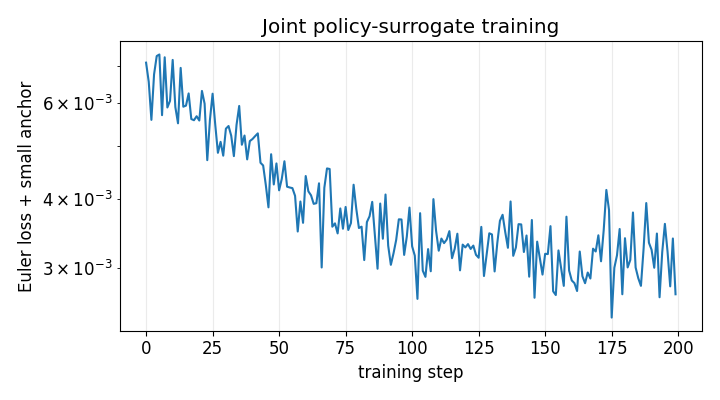

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.semilogy(losses)
ax.set_xlabel("training step")
ax.set_ylabel("Euler loss + small anchor")
ax.set_title("Joint policy-surrogate training")
plt.tight_layout()

T_BURN = 100
T_SIM  = 500
beta_grid = np.round(np.arange(beta_lo, beta_hi + 1e-10, 0.0025), 4)
rho_grid  = np.round(np.arange(rho_lo,  rho_hi  + 1e-10, 0.0100), 4)
BB, RR = np.meshgrid(beta_grid, rho_grid, indexing="xy")
theta_grid = np.column_stack([BB.ravel(), RR.ravel()]).astype(np.float32)

print(f"beta grid points: {len(beta_grid)}")
print(f"rho grid points : {len(rho_grid)}")
print(f"total candidates: {len(theta_grid)}")
print(f"truth in grid   : {np.any(np.isclose(theta_grid[:,0], beta_true) & np.isclose(theta_grid[:,1], rho_true))}")


In [5]:
def simulate_many_theta(policy, theta_values, T_burn=T_BURN, T_sim=T_SIM, seed=SEED + 123, K0=3.0):
    """Vectorized simulation for many (beta, rho) candidates under one common shock path."""
    torch.manual_seed(seed)
    theta_values = np.asarray(theta_values, dtype=np.float32)
    n = len(theta_values)
    T = T_burn + T_sim

    beta = torch.tensor(theta_values[:, 0:1], dtype=torch.float32, device=device)
    rho  = torch.tensor(theta_values[:, 1:2], dtype=torch.float32, device=device)
    z_t  = torch.ones(n, 1, device=device)
    K_t  = torch.full((n, 1), float(K0), dtype=torch.float32, device=device)
    shocks = torch.randn(T, 1, device=device)

    C_all, I_all, Y_all = [], [], []
    with torch.no_grad():
        for t in range(T):
            X_t = torch.cat([z_t, K_t, beta, rho], dim=1)
            s_t = policy(X_t)
            Y_t = z_t * K_t**alpha
            I_t = Y_t * s_t
            C_t = Y_t * (1.0 - s_t)
            K_tp1 = (1.0 - delta) * K_t + I_t
            z_tp1 = torch.exp(rho * torch.log(z_t) + sigma_z * shocks[t])
            if t >= T_burn:
                C_all.append(C_t.squeeze(1).cpu().numpy())
                I_all.append(I_t.squeeze(1).cpu().numpy())
                Y_all.append(Y_t.squeeze(1).cpu().numpy())
            z_t, K_t = z_tp1, K_tp1
    return np.stack(C_all), np.stack(I_all), np.stack(Y_all)


def autocorr_columns(X):
    x0 = X[:-1] - X[:-1].mean(axis=0)
    x1 = X[1:]  - X[1:].mean(axis=0)
    denom = np.sqrt((x0 * x0).sum(axis=0) * (x1 * x1).sum(axis=0))
    return (x0 * x1).sum(axis=0) / denom


def compute_moments_many(C, I, Y):
    dlog_C = np.diff(np.log(C), axis=0)
    log_Y  = np.log(Y)
    return np.column_stack([
        np.mean(I / Y, axis=0),
        np.std(dlog_C, axis=0),
        autocorr_columns(dlog_C),
        autocorr_columns(log_Y),
    ])

moment_names = [
    "Mean savings",
    r"Std($\Delta\log C$)",
    r"Autocorr($\Delta\log C$)",
    r"Autocorr($\log Y$)",
]

C_grid, I_grid, Y_grid = simulate_many_theta(policy, theta_grid)
moments_flat = compute_moments_many(C_grid, I_grid, Y_grid)
moments = moments_flat.reshape(len(rho_grid), len(beta_grid), len(moment_names))

idx_beta_true = int(np.where(np.isclose(beta_grid, beta_true))[0][0])
idx_rho_true  = int(np.where(np.isclose(rho_grid,  rho_true))[0][0])
target_moments = moments[idx_rho_true, idx_beta_true].copy()

print(f"Synthetic sample length after burn-in: {T_SIM}")
print("\nTarget moments:")
for name, value in zip(moment_names, target_moments):
    print(f"  {name:<28s}: {value:+.6f}")


Synthetic sample length after burn-in: 500

Target moments:
  Mean savings                : +0.288479
  Std($\Delta\log C$)         : +0.033061
  Autocorr($\Delta\log C$)    : +0.075110
  Autocorr($\log Y$)          : +0.949035


## 3. SMM criterion surfaces

We compare two moment sets:

- a weak two-moment set, which is intentionally dominated by dynamic persistence information and produces a shallow direction in \(\beta\);
- the over-identified four-moment set, which adds the level of the savings rate and produces a localized minimum.

This is the identification lesson: the estimator is only as informative as the moments used to build the criterion.


In [6]:
mask_weak = np.array([False, True, True, False])   # dynamic moments only: weak in beta
mask_over = np.array([True,  True, True, True])     # preferred over-identified specification


def criterion_surface(mask):
    diff = moments[:, :, mask] - target_moments[mask]
    return np.sum(diff * diff, axis=2)

Q_weak = criterion_surface(mask_weak)
Q_over = criterion_surface(mask_over)

idx_weak = np.unravel_index(int(np.argmin(Q_weak)), Q_weak.shape)
idx_over = np.unravel_index(int(np.argmin(Q_over)), Q_over.shape)

bhat_weak, rhat_weak = float(beta_grid[idx_weak[1]]), float(rho_grid[idx_weak[0]])
bhat_over, rhat_over = float(beta_grid[idx_over[1]]), float(rho_grid[idx_over[0]])

print("Weak two-moment SMM estimate")
print(f"  beta_hat = {bhat_weak:.4f}, rho_hat = {rhat_weak:.4f}, Q = {Q_weak[idx_weak]:.3e}")
print("Over-identified four-moment SMM estimate")
print(f"  beta_hat = {bhat_over:.4f}, rho_hat = {rhat_over:.4f}, Q = {Q_over[idx_over]:.3e}")
print("Truth")
print(f"  beta_true = {beta_true:.4f}, rho_true = {rho_true:.4f}")


Weak two-moment SMM estimate
  beta_hat = 0.9600, rho_hat = 0.9000, Q = 0.000e+00
Over-identified four-moment SMM estimate
  beta_hat = 0.9600, rho_hat = 0.9000, Q = 0.000e+00
Truth
  beta_true = 0.9600, rho_true = 0.9000


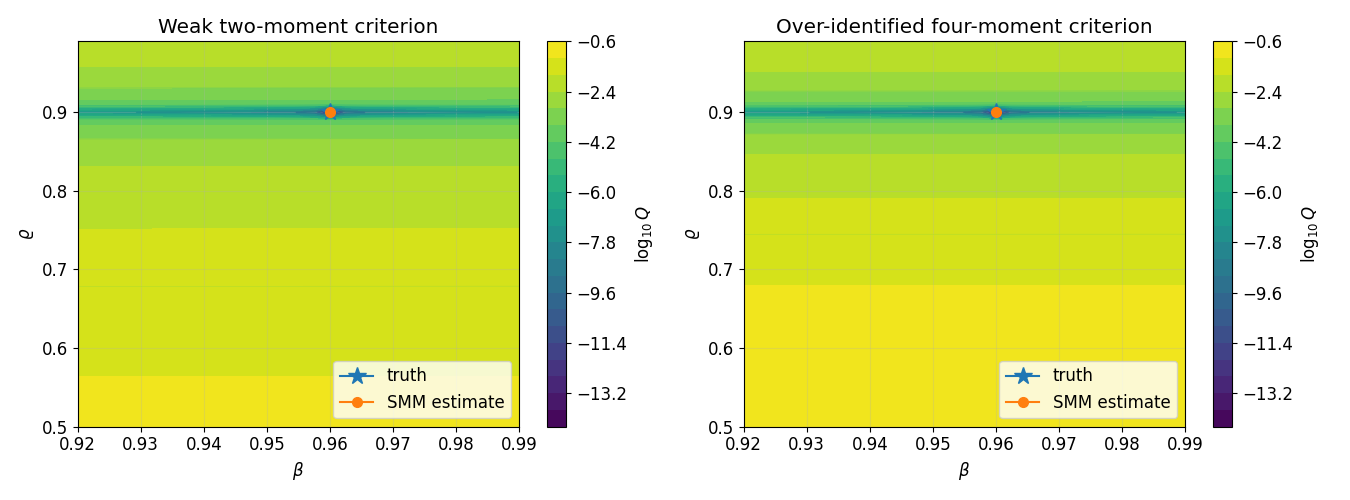

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
for ax, Qsurf, title, bhat, rhat in [
    (axes[0], Q_weak, "Weak two-moment criterion", bhat_weak, rhat_weak),
    (axes[1], Q_over, "Over-identified four-moment criterion", bhat_over, rhat_over),
]:
    Z = np.log10(np.maximum(Qsurf, 1e-14))
    cs = ax.contourf(BB, RR, Z, levels=24)
    ax.contour(BB, RR, Z, levels=10, linewidths=0.6)
    ax.plot(beta_true, rho_true, marker="*", markersize=13, label="truth")
    ax.plot(bhat, rhat, marker="o", markersize=7, label="SMM estimate")
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$\varrho$")
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.colorbar(cs, ax=ax, label=r"$\log_{10} Q$")
plt.tight_layout()
_save_fig(fig, "joint_criterion_contour.pdf")


## 4. Moment match and local identification diagnostics

The over-identified estimate is the preferred specification in this short notebook.  The finite-difference Jacobian below reports how the selected moments move locally with \((\beta,\varrho)\).  A small singular value corresponds to a weakly identified direction.


In [8]:
fitted_moments = moments[idx_over]

print("Matched moments at the over-identified estimate")
print("-" * 76)
print(f"{'moment':<28s} {'target':>12s} {'fit':>12s} {'diff':>12s}")
print("-" * 76)
for name, target, fit in zip(moment_names, target_moments, fitted_moments):
    print(f"{name:<28s} {target:>+12.6f} {fit:>+12.6f} {fit-target:>+12.2e}")
print("-" * 76)
print(f"distance to truth in beta: {abs(bhat_over - beta_true):.4e}")
print(f"distance to truth in rho : {abs(rhat_over - rho_true):.4e}")

# Central finite differences on the moment grid at the truth.
dbeta = beta_grid[1] - beta_grid[0]
drho  = rho_grid[1]  - rho_grid[0]
dm_dbeta = (moments[idx_rho_true, idx_beta_true + 1] - moments[idx_rho_true, idx_beta_true - 1]) / (2.0 * dbeta)
dm_drho  = (moments[idx_rho_true + 1, idx_beta_true] - moments[idx_rho_true - 1, idx_beta_true]) / (2.0 * drho)
M = np.column_stack([dm_dbeta, dm_drho])
U, singular_values, Vt = np.linalg.svd(M[mask_over, :], full_matrices=False)

print("\nFinite-difference Jacobian dm/d(beta,rho) at the truth")
print(f"{'moment':<28s} {'d/dbeta':>12s} {'d/drho':>12s}")
for name, row in zip(moment_names, M):
    print(f"{name:<28s} {row[0]:>+12.4e} {row[1]:>+12.4e}")
print(f"\nSingular values, over-identified moments: {singular_values}")
print(f"Condition number: {singular_values[0] / singular_values[-1]:.2e}")
print(f"Weak direction in (beta,rho): {Vt[-1]}")


Matched moments at the over-identified estimate
----------------------------------------------------------------------------
moment                             target          fit         diff
----------------------------------------------------------------------------
Mean savings                    +0.288479    +0.288479    +0.00e+00
Std($\Delta\log C$)             +0.033061    +0.033061    +0.00e+00
Autocorr($\Delta\log C$)        +0.075110    +0.075110    +0.00e+00
Autocorr($\log Y$)              +0.949035    +0.949035    +0.00e+00
----------------------------------------------------------------------------
distance to truth in beta: 0.0000e+00
distance to truth in rho : 0.0000e+00

Finite-difference Jacobian dm/d(beta,rho) at the truth
moment                            d/dbeta       d/drho
Mean savings                  -1.6391e-03  +2.6293e-02
Std($\Delta\log C$)           +1.3486e-04  +9.4604e-04
Autocorr($\Delta\log C$)      -5.9351e-03  +9.8582e-01
Autocorr($\log Y$)           

## 5. Estimate on the surrogate and policy match

These final plots connect the SMM estimate back to the trained policy surrogate.


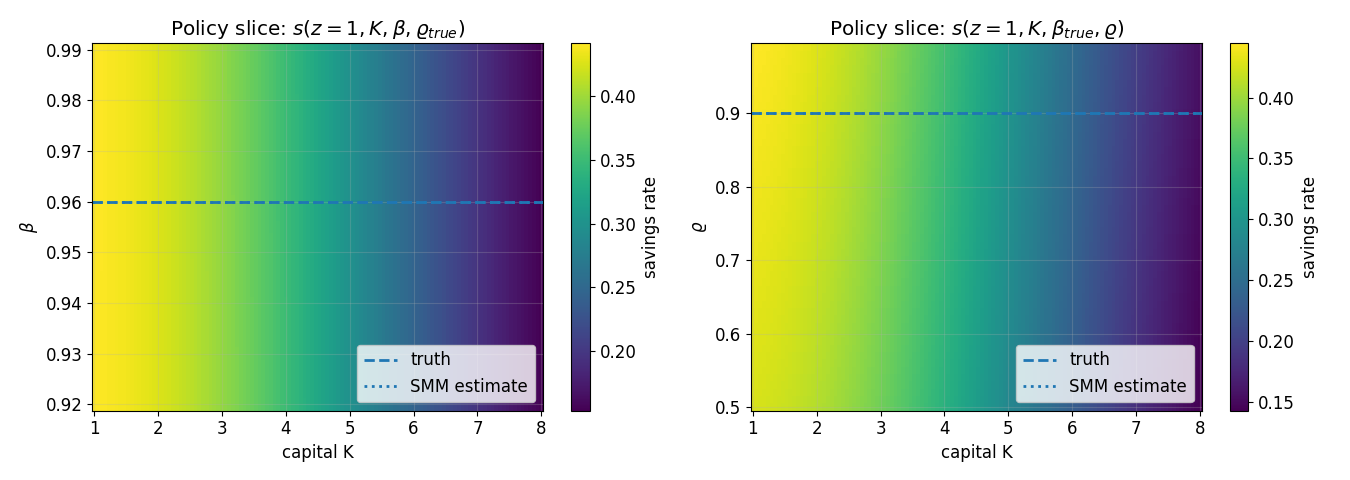

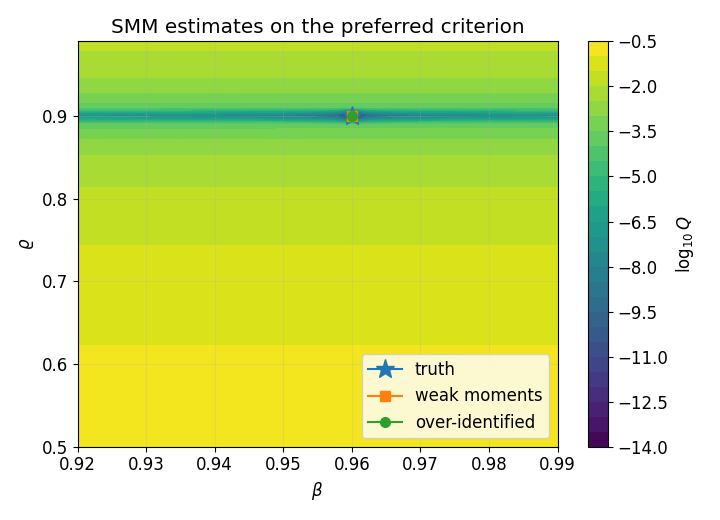

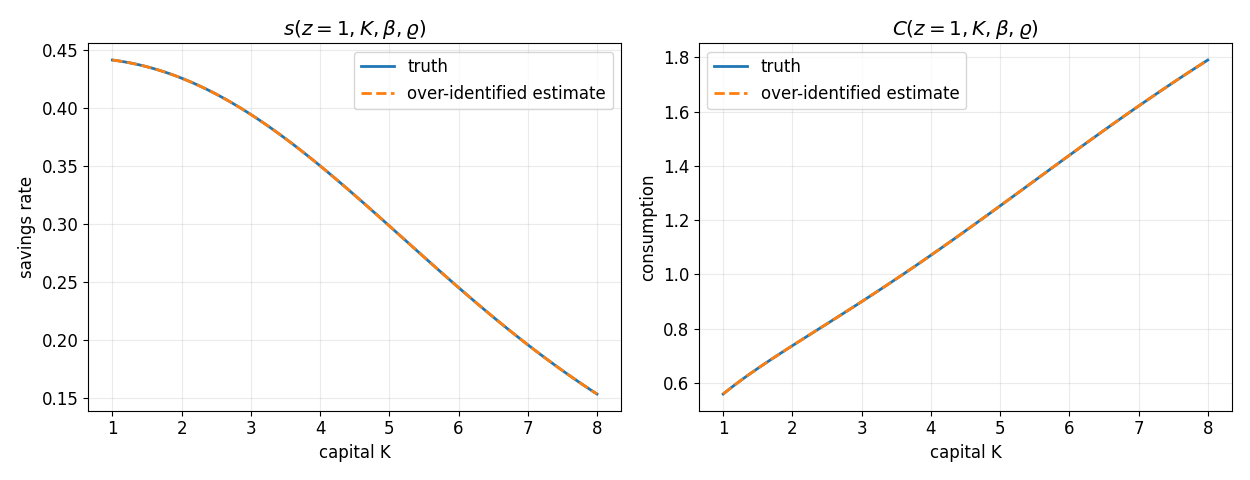

In [9]:
K_plot = np.linspace(1.0, 8.0, 120)
beta_plot = beta_grid
rho_plot = rho_grid

# Slice 1: vary beta, hold rho fixed at the truth.
KK_b, BB_b = np.meshgrid(K_plot, beta_plot, indexing="xy")
X_b = torch.tensor(
    np.column_stack([np.ones(KK_b.size), KK_b.ravel(), BB_b.ravel(), np.full(KK_b.size, rho_true)]),
    dtype=torch.float32, device=device,
)
# Slice 2: vary rho, hold beta fixed at the truth.
KK_r, RR_r = np.meshgrid(K_plot, rho_plot, indexing="xy")
X_r = torch.tensor(
    np.column_stack([np.ones(KK_r.size), KK_r.ravel(), np.full(KK_r.size, beta_true), RR_r.ravel()]),
    dtype=torch.float32, device=device,
)
with torch.no_grad():
    S_b = policy(X_b).cpu().numpy().reshape(KK_b.shape)
    S_r = policy(X_r).cpu().numpy().reshape(KK_r.shape)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
ax = axes[0]
im = ax.pcolormesh(KK_b, BB_b, S_b, shading="auto")
ax.axhline(beta_true, linestyle="--", linewidth=2, label="truth")
ax.axhline(bhat_over, linestyle=":", linewidth=2, label="SMM estimate")
ax.set_xlabel("capital K")
ax.set_ylabel(r"$\beta$")
ax.set_title(r"Policy slice: $s(z=1,K,\beta,\varrho_{true})$")
ax.legend(loc="lower right")
plt.colorbar(im, ax=ax, label="savings rate")

ax = axes[1]
im = ax.pcolormesh(KK_r, RR_r, S_r, shading="auto")
ax.axhline(rho_true, linestyle="--", linewidth=2, label="truth")
ax.axhline(rhat_over, linestyle=":", linewidth=2, label="SMM estimate")
ax.set_xlabel("capital K")
ax.set_ylabel(r"$\varrho$")
ax.set_title(r"Policy slice: $s(z=1,K,\beta_{true},\varrho)$")
ax.legend(loc="lower right")
plt.colorbar(im, ax=ax, label="savings rate")
plt.tight_layout()
_save_fig(fig, "joint_surrogate_with_estimates.pdf")

# Estimates overlay on the preferred criterion.
fig, ax = plt.subplots(figsize=(7.2, 5.2))
Z = np.log10(np.maximum(Q_over, 1e-14))
cs = ax.contourf(BB, RR, Z, levels=26)
ax.contour(BB, RR, Z, levels=10, linewidths=0.6)
ax.plot(beta_true, rho_true, marker="*", markersize=14, label="truth")
ax.plot(bhat_weak, rhat_weak, marker="s", markersize=7, label="weak moments")
ax.plot(bhat_over, rhat_over, marker="o", markersize=7, label="over-identified")
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$\varrho$")
ax.set_title("SMM estimates on the preferred criterion")
ax.legend(loc="lower right")
plt.colorbar(cs, ax=ax, label=r"$\log_{10} Q$")
plt.tight_layout()
_save_fig(fig, "joint_estimates_overlay.pdf")

# Policy and consumption curves at the truth and over-identified estimate.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
for label, beta_val, rho_val, style in [
    ("truth", beta_true, rho_true, "-"),
    ("over-identified estimate", bhat_over, rhat_over, "--"),
]:
    X_plot = torch.tensor(
        np.column_stack([np.ones_like(K_plot), K_plot, np.full_like(K_plot, beta_val), np.full_like(K_plot, rho_val)]),
        dtype=torch.float32, device=device,
    )
    with torch.no_grad():
        s_plot = policy(X_plot).cpu().numpy().ravel()
    Y_plot = K_plot**alpha
    C_plot = (1.0 - s_plot) * Y_plot
    axes[0].plot(K_plot, s_plot, linestyle=style, linewidth=2, label=label)
    axes[1].plot(K_plot, C_plot, linestyle=style, linewidth=2, label=label)

axes[0].set_xlabel("capital K")
axes[0].set_ylabel("savings rate")
axes[0].set_title(r"$s(z=1,K,\beta,\varrho)$")
axes[0].legend()
axes[1].set_xlabel("capital K")
axes[1].set_ylabel("consumption")
axes[1].set_title(r"$C(z=1,K,\beta,\varrho)$")
axes[1].legend()
plt.tight_layout()
_save_fig(fig, "joint_policy_comparison.pdf")


## Summary

The joint notebook now focuses on the essential structural-estimation message:

- a single four-input policy surrogate covers the whole \((\beta,\varrho)\) rectangle;
- common random numbers make the simulated moment map deterministic;
- contour plots reveal which moments identify which parameter directions;
- the over-identified SMM criterion recovers the synthetic truth accurately.

The removed GP/active-learning machinery is valuable for high-throughput estimation, but it should be presented after this core workflow rather than inside the introductory notebook.


In [10]:
assert abs(bhat_over - beta_true) <= 0.0025 + 1e-12
assert abs(rhat_over - rho_true) <= 0.0100 + 1e-12
assert beta_lo < bhat_over < beta_hi and rho_lo < rhat_over < rho_hi
print("Validation passed: joint SMM recovers the synthetic parameters.")


Validation passed: joint SMM recovers the synthetic parameters.
